In [ ]:
import os
import numpy as np

# =========================
# Settings
# =========================
DATASET_PATH = "dataset"
SAMPLE_RATE = 16000
WINDOW_SIZE = SAMPLE_RATE   # 1 second windows

label_map = {
    "clap": 0,
    "snap": 1,
    "tap": 2,
    "silence": 3
}

X = []
y = []

# =========================
# Helper: check numeric line
# =========================
def is_integer_line(s):
    s = s.strip()
    if s == "":
        return False
    if s in ["START", "STOP"]:
        return False
    try:
        int(s)
        return True
    except ValueError:
        return False

# =========================
# Process one file
# =========================
def process_file(filepath, label):
    with open(filepath, "r") as f:
        data = f.readlines()

    numeric_data = [int(x.strip()) for x in data if is_integer_line(x)]

    if len(numeric_data) == 0:
        print(f"Skipped empty/non-numeric file: {filepath}")
        return

    signal = np.array(numeric_data, dtype=np.int16)

    num_windows = len(signal) // WINDOW_SIZE

    for i in range(num_windows):
        start = i * WINDOW_SIZE
        end = start + WINDOW_SIZE
        window = signal[start:end]

        if len(window) == WINDOW_SIZE:
            X.append(window)
            y.append(label)

# =========================
# Walk through dataset
# =========================
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    if class_name not in label_map:
        continue

    label = label_map[class_name]

    for file in os.listdir(class_path):
        if file.endswith(".txt") or file.endswith(".csv"):
            filepath = os.path.join(class_path, file)
            process_file(filepath, label)

# =========================
# Convert to numpy
# =========================
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# optional: show class counts
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    class_name = [k for k, v in label_map.items() if v == u][0]
    print(f"{class_name}: {c}")

X shape: (183, 16000)
y shape: (183,)
Class distribution:
clap: 48
snap: 45
tap: 45
silence: 45


In [ ]:
import librosa

def extract_mfcc(signal):
    # normalize
    signal = signal.astype(float)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=16000,
        n_mfcc=13
    )

    return mfcc

X_mfcc = []

for i in range(len(X)):
    mfcc = extract_mfcc(X[i])
    X_mfcc.append(mfcc)

X_mfcc = np.array(X_mfcc)

print("MFCC shape:", X_mfcc.shape)

MFCC shape: (183, 13, 32)


In [ ]:
X_mfcc = X_mfcc[..., np.newaxis]

print("Final shape:", X_mfcc.shape)

Final shape: (183, 13, 32, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_mfcc, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (146, 13, 32, 1)
Test: (37, 13, 32, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(13,32,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')  # 4 کلاس
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 11, 30, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 15, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 13, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,108 (43.39 KB)

 Trainable params: 11,108 (43.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0190
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0181
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9730 - val_loss: 0.0258
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0190
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0203
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0167
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0192
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 1.0000 - loss: 0.0129
Test Accuracy: 1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step


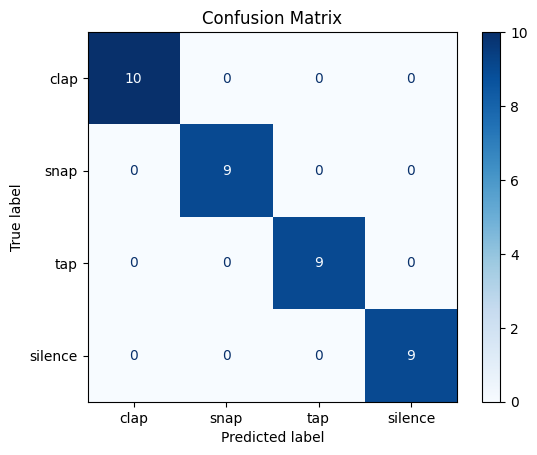

              precision    recall  f1-score   support

        clap       1.00      1.00      1.00        10
        snap       1.00      1.00      1.00         9
         tap       1.00      1.00      1.00         9
     silence       1.00      1.00      1.00         9

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

labels = ["clap", "snap", "tap", "silence"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=labels))

In [ ]:
model.save("gesture_mfcc_model.h5")

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("gesture_mfcc_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully.")

Saved artifact at '/tmp/tmp8l_twoxv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136936516319184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136936516320336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136936516318992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136936516321104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136936516318224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136936516317840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136936516320720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136936516320528: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved successfully.


In [ ]:
from google.colab import files
files.download("gesture_mfcc_model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with open("gesture_mfcc_model.tflite", "rb") as f:
    tflite_bytes = f.read()

with open("model_data.h", "w") as f:
    f.write("const unsigned char model_data[] = {")
    for i, b in enumerate(tflite_bytes):
        if i % 12 == 0:
            f.write("\n  ")
        f.write(f"0x{b:02x}, ")
    f.write("\n};\n")
    f.write(f"const unsigned int model_data_len = {len(tflite_bytes)};\n")

print("model_data.h created.")

model_data.h created.


In [ ]:
from google.colab import files
files.download("model_data.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>